In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import zipfile

zip_path = "/content/drive/MyDrive/AI_ML/Data/FruitinAmazon.zip"
extract_path = "/content/FruitData"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed!")

Extraction Completed!


In [7]:
train_dir = "/content/FruitData/FruitinAmazon/train"
test_dir  = "/content/FruitData/FruitinAmazon/test"

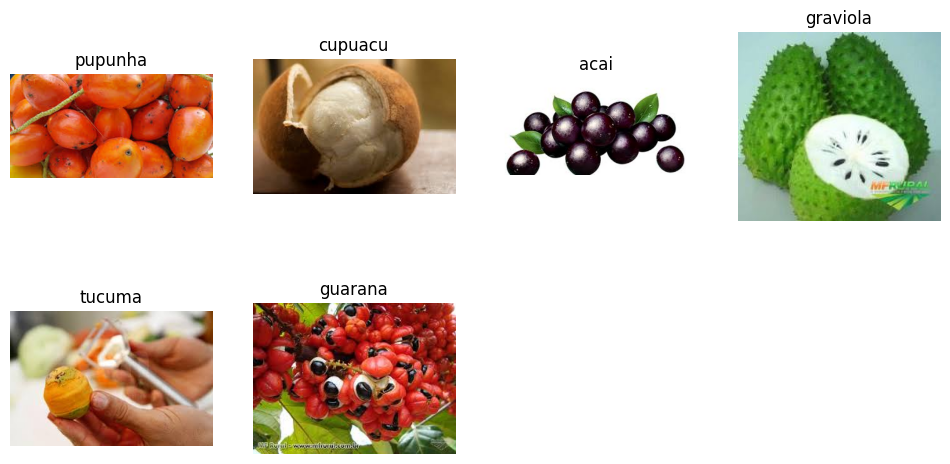

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = [c for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))]

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    images = [img for img in os.listdir(cls_path) if img.endswith(('.jpg', '.png', '.jpeg'))]

    img_path = os.path.join(cls_path, random.choice(images))
    img = Image.open(img_path)

    plt.subplot(2, len(classes)//2 + 1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [10]:
from PIL import Image

corrupted = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [11]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [12]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [13]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [14]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.1122 - loss: 1.9387

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - accuracy: 0.1389 - loss: 1.9235 - val_accuracy: 0.2222 - val_loss: 1.9918
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.2931 - loss: 1.7710

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.2778 - loss: 1.7366 - val_accuracy: 0.1667 - val_loss: 1.8459
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.4465 - loss: 1.5722

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.4722 - loss: 1.5145 - val_accuracy: 0.2778 - val_loss: 1.7437
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.4906 - loss: 1.2889

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 414ms/step - accuracy: 0.4583 - loss: 1.2831 - val_accuracy: 0.2778 - val_loss: 1.7238
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 355ms/step - accuracy: 0.7222 - loss: 0.9573 - val_accuracy: 0.3333 - val_loss: 1.7514
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 536ms/step - accuracy: 0.7639 - loss: 0.7911 - val_accuracy: 0.2778 - val_loss: 1.8358
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 346ms/step - accuracy: 0.9444 - loss: 0.4323 - val_accuracy: 0.2778 - val_loss: 1.9122
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.9861 - loss: 0.2294 - val_accuracy: 0.3889 - val_loss: 2.1326
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 0.9861 - loss: 0.1433 - val_accuracy: 0.2222 - val_loss: 2.1756
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - accuracy: 0.9722 - loss: 0.0939 - val_accuracy: 0.3333 - val_loss: 1.8241
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - accuracy: 0.9861 - loss: 0.0713 - val_accuracy: 0.4444 - val_loss: 2

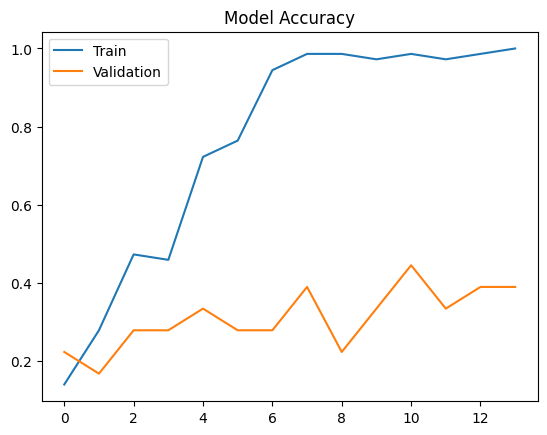

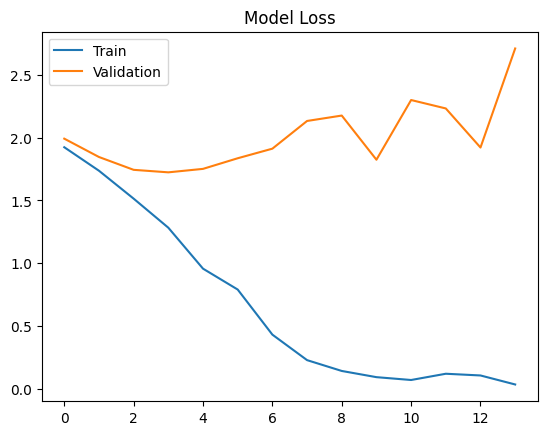

In [17]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [18]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4667 - loss: 1.3380
Test Accuracy: 0.46666666865348816


In [19]:
model.save("fruit_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_model.h5")

In [20]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
              precision    recall  f1-score   support

        acai       0.43      0.60      0.50         5
     cupuacu       0.36      0.80      0.50         5
    graviola       1.00      0.40      0.57         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.56      1.00      0.71         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.47        30
   macro avg       0.39      0.47      0.38        30
weighted avg       0.39      0.47      0.38        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
